In [58]:
# Older versions of Jupyter Notebooks and matplotlib required this magic command 
# %matplotlib inline

# Import matplotlib and matplotlib.pyplot
import matplotlib
import matplotlib.pyplot as plt

print(f"matplotlib version: {matplotlib.__version__}")

matplotlib version: 3.10.0


# 2 ways of creating plots

There are two main ways of creating plots in matplotlib.

matplotlib.pyplot.plot() - Recommended for simple plots (e.g. x and y).

matplotlib.pyplot.XX (where XX can be one of many methods, this is known as the object-oriented API) - 
Recommended for more complex plots (for example plt.subplots() to create multiple plots on the same Figure, we'll get to this later).

Both of these methods are still often created by building off import matplotlib.pyplot as plt as a base.

[]

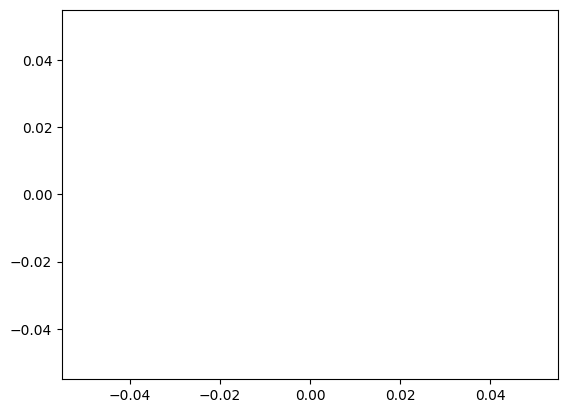

In [59]:
# Create a simple plot, without the semi-colon
plt.plot()

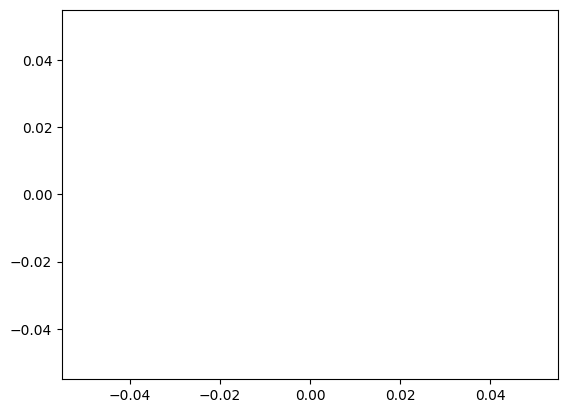

In [60]:
# With the semi-colon
plt.plot();

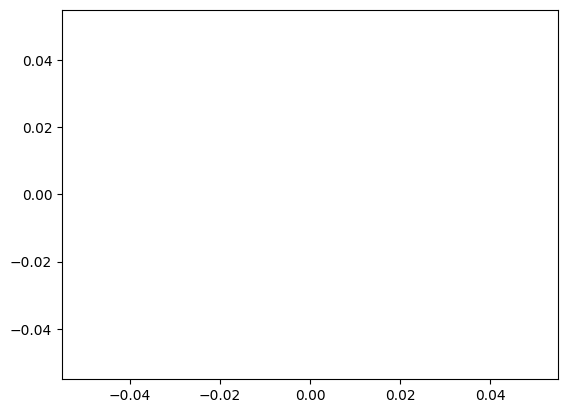

In [61]:
# You could use plt.show() if you want
plt.plot()
plt.show()

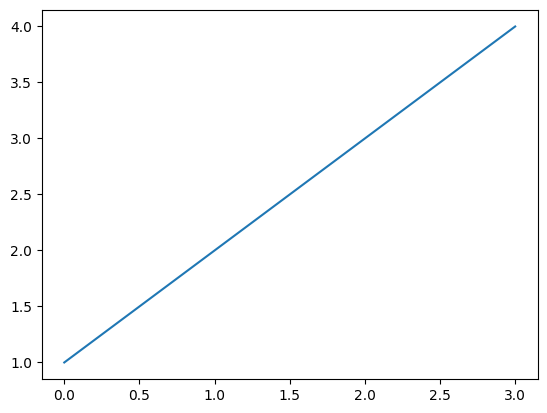

In [62]:
# Let's add some data
plt.plot([1, 2, 3, 4]);

In [63]:
# Create some data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

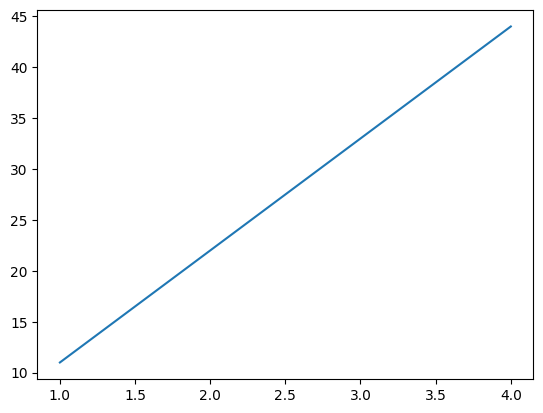

In [64]:
# Now a y-value too!
plt.plot(x, y);

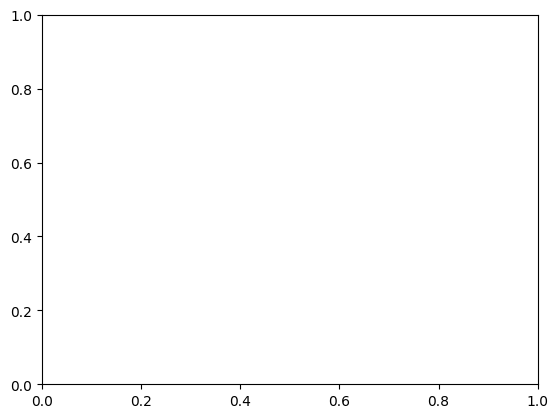

In [65]:
# Creating a plot with the object-orientated verison
fig = plt.figure() # create a figure
ax = fig.add_subplot() # add an axes 
plt.show()

A Figure (e.g. fig = plt.figure()) is the final image in matplotlib (and it may contain one or more Axes), often shortened to fig.

- The Axes are an individual plot (e.g. ax = fig.add_subplot()), often shorted to ax.
- One Figure can contain one or more Axes.
- The Axis are x (horizontal), y (vertical), z (depth).


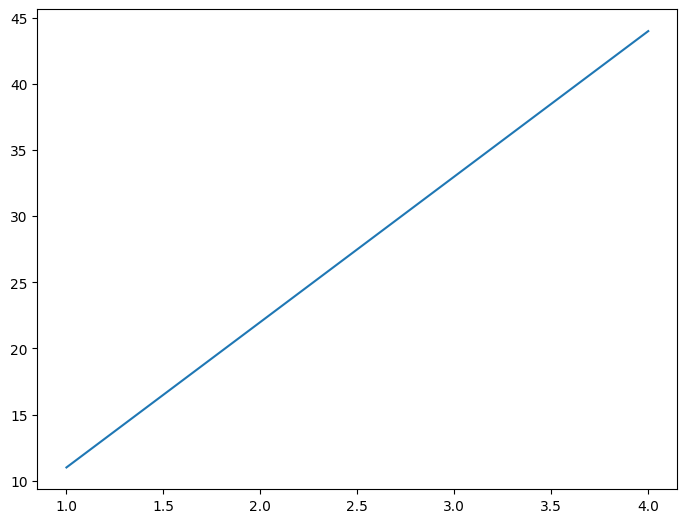

In [66]:
# Add some data to our previous plot 
fig = plt.figure()
ax = fig.add_axes([1, 1, 1, 1])
ax.plot(x, y)
plt.show()

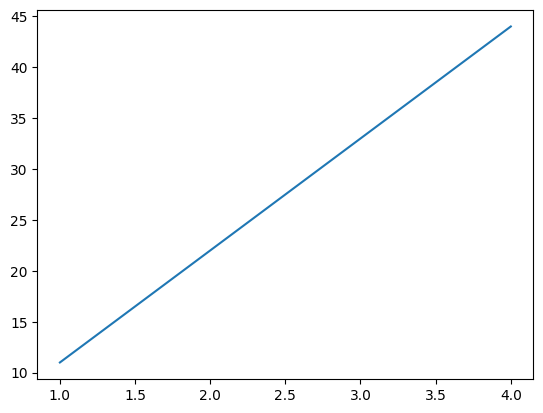

In [67]:
# Create a Figure and multiple potential Axes and add some data
fig, ax = plt.subplots()
ax.plot(x, y);

# Anatomy of a Matplotlib Figure

Matplotlib offers almost unlimited options for creating plots.

However, let's break down some of the main terms.

- Figure - The base canvas of all matplotlib plots. The overall thing you're plotting is a Figure, often shortened to fig.

- Axes - One Figure can have one or multiple Axes, for example, a Figure with multiple suplots could have 4 Axes (2 rows and 2 columns). Often shortened to ax.

- Axis - A particular dimension of an Axes, for example, the x-axis or y-axis.<br><br>


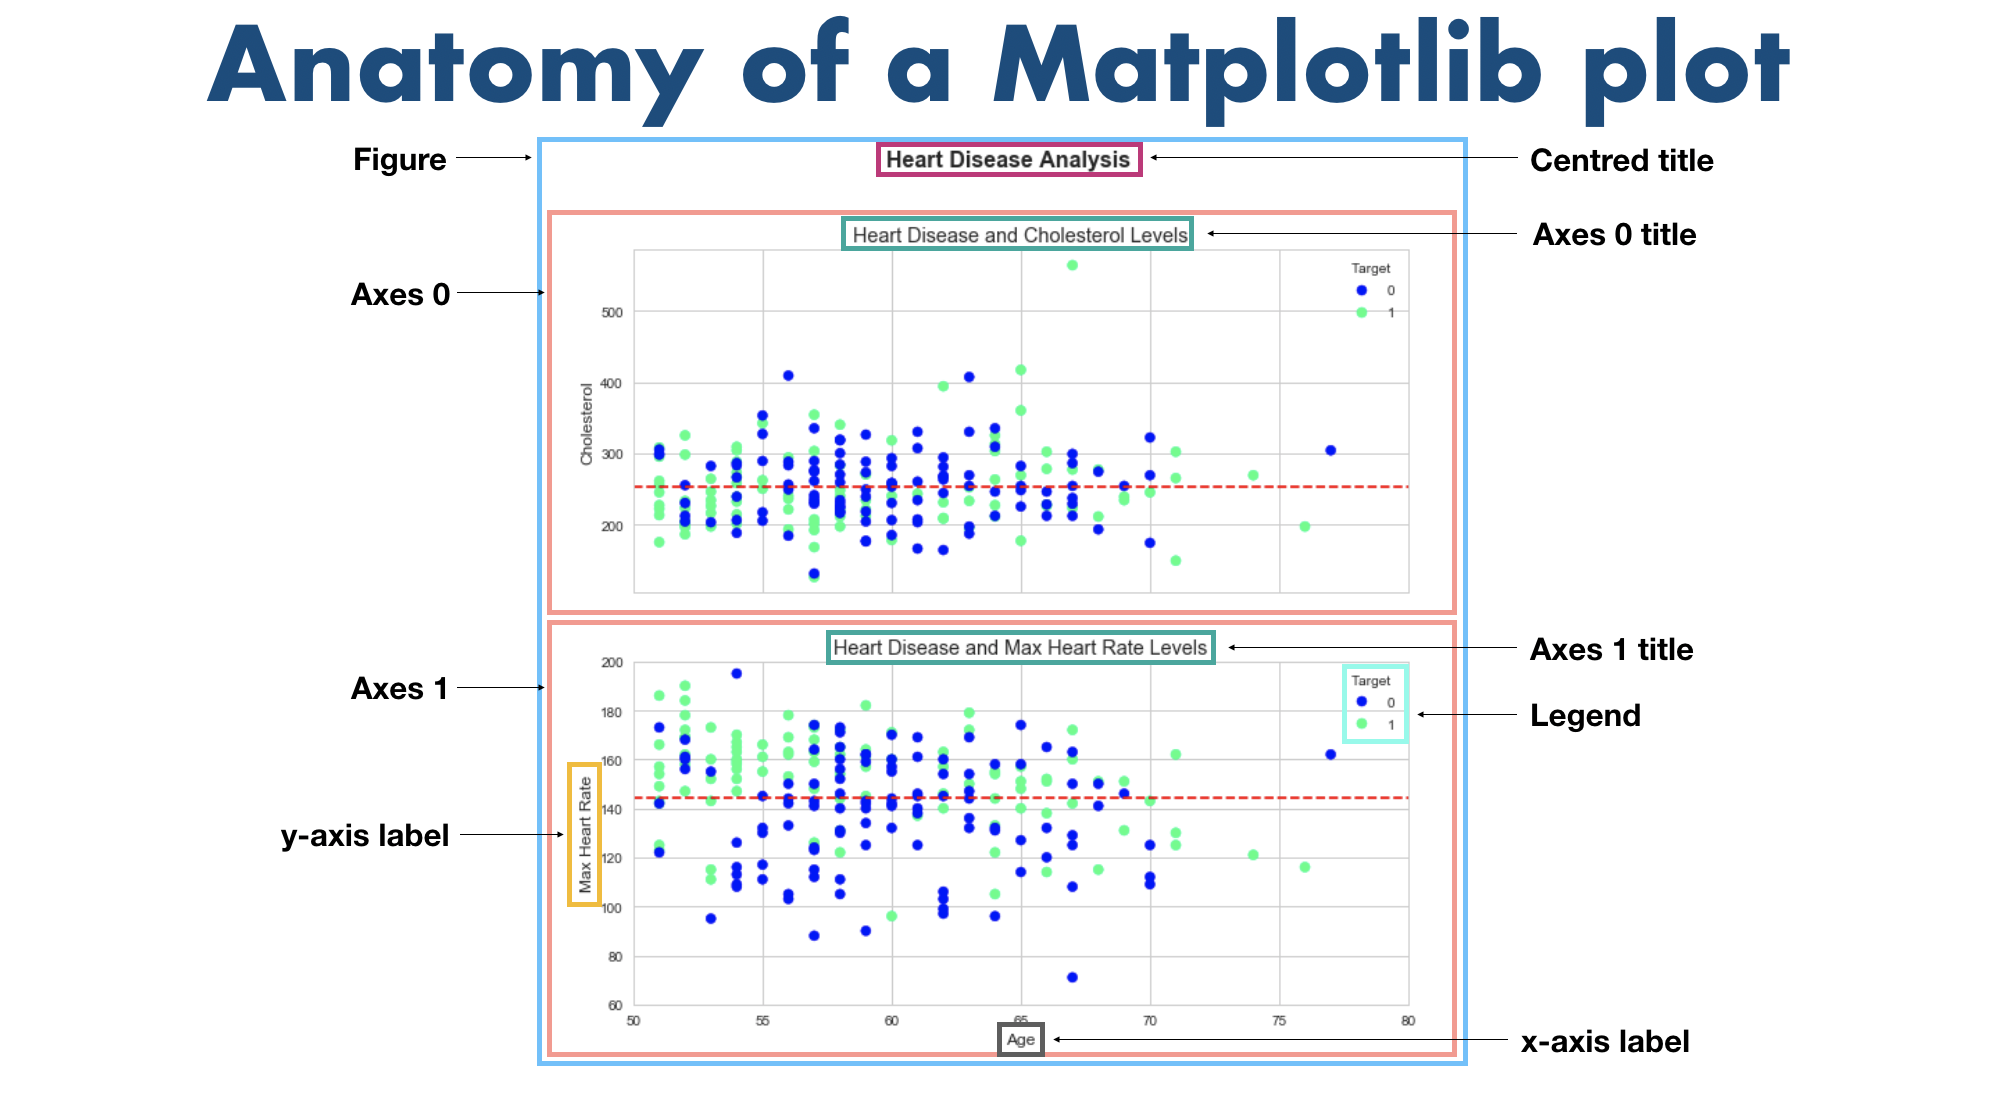



In [68]:
# This is where the object orientated name comes from 
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

# A quick Matplotlib Workflow

The following workflow is a standard practice when creating a matplotlib plot:

- Import matplotlib - For example, import matplotlib.pyplot as plt).

- Prepare data - This may be from an existing dataset (data analysis) or from the outputs of a machine learning model (data science).

- Setup the plot - In other words, create the Figure and various Axes.

- Plot data to the Axes - Send the relevant data to the target Axes.

- Cutomize the plot - Add a title, decorate the colours, label each Axis.

- Save (optional) and show - See what your masterpiece looks like and save it to file if necessary.


[Text(0.5, 1.0, 'Sample Simple Plot'),
 Text(0.5, 0, 'x-axis'),
 Text(0, 0.5, 'y-axis')]

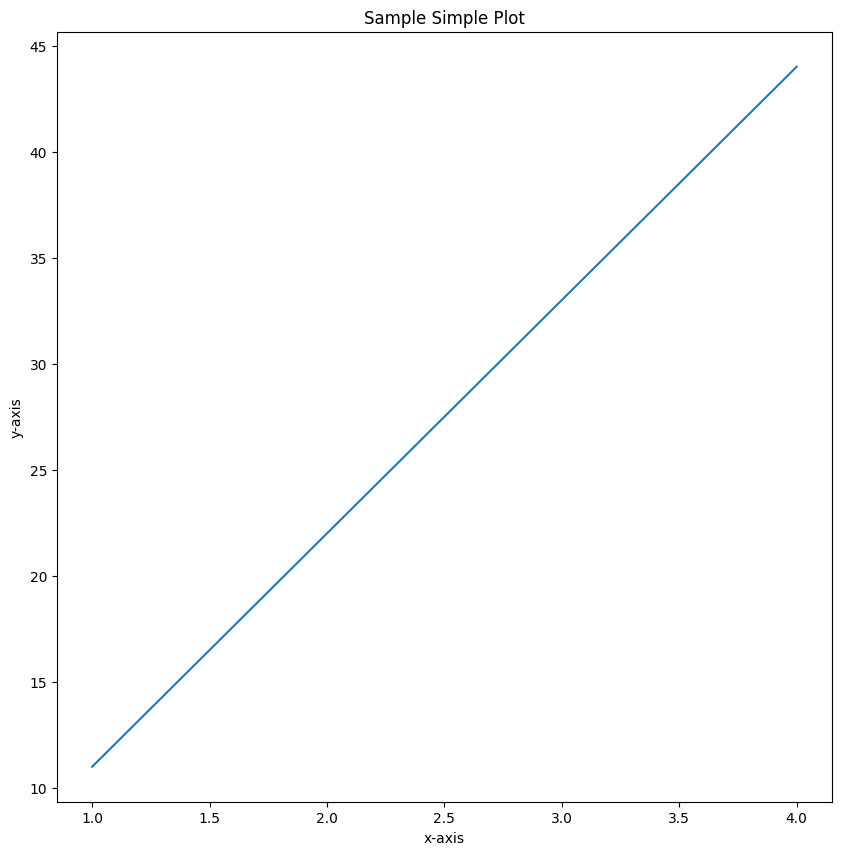

In [69]:
# A matplotlib workflow

# 0. Import and get matplotlib ready
# %matplotlib inline # Not necessary in newer versions of Jupyter (e.g. 2022 onwards)
import matplotlib.pyplot as plt

# 1. Prepare data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# 2. Setup plot (Figure and Axes)
fig, ax = plt.subplots(figsize=(10,10))

# 3. Plot data
ax.plot(x, y)

# 4. Customize plot
ax.set(title="Sample Simple Plot", xlabel="x-axis", ylabel="y-axis")

# 5. Save & show


# Making the most common type of plots using NumPy arrays

Most of figuring out what kind of plot to use is getting a feel for the data, then seeing what kind of plot suits it best.

Matplotlib visualizations are built on NumPy arrays. So in this section we'll build some of the most common types of plots using NumPy arrays.

- Line plot - ax.plot() (this is the default plot in matplotlib)

- Scatter plot - ax.scatter()

- Bar plot - ax.bar()

- Histogram plot - ax.hist()

In [70]:
import numpy as np

In [71]:
# Create an array
x = np.linspace(0, 10, 100)
x[:10]

array([0.        , 0.1010101 , 0.2020202 , 0.3030303 , 0.4040404 ,
       0.50505051, 0.60606061, 0.70707071, 0.80808081, 0.90909091])

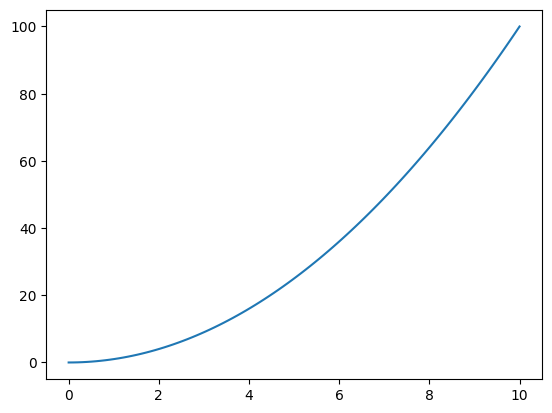

In [72]:
# The default plot is line
fig, ax = plt.subplots()
ax.plot(x, x**2);

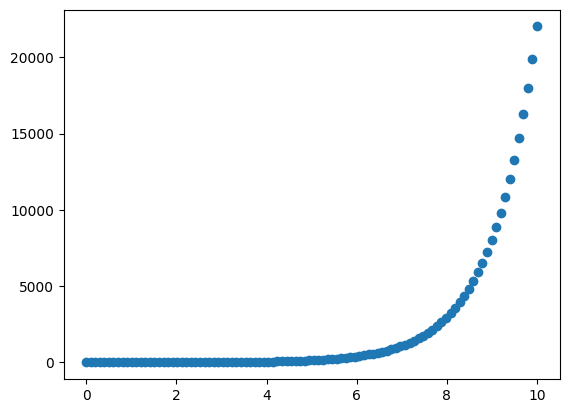

In [73]:
# Need to recreate our figure and axis instances when we want a new figure
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x));

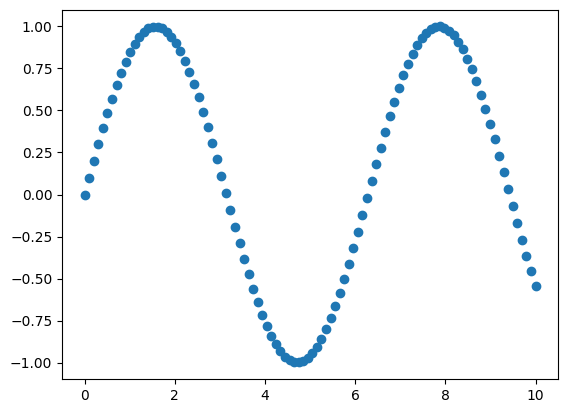

In [74]:
fig, ax = plt.subplots()
ax.scatter(x, np.sin(x));

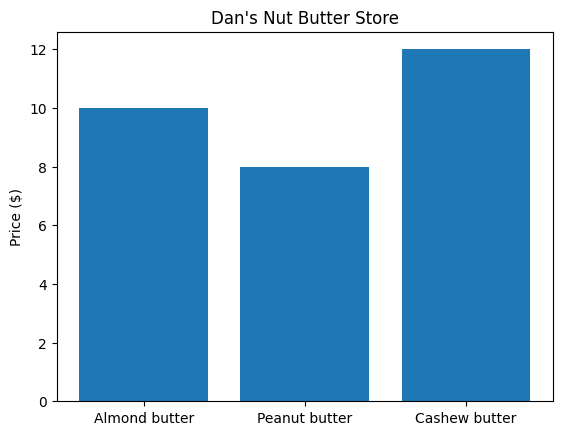

In [75]:
# You can make plots from a dictionary
nut_butter_prices = {"Almond butter": 10,
                     "Peanut butter": 8,
                     "Cashew butter": 12}

fig, ax = plt.subplots()
ax.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax.set(title="Dan's Nut Butter Store", ylabel="Price ($)");

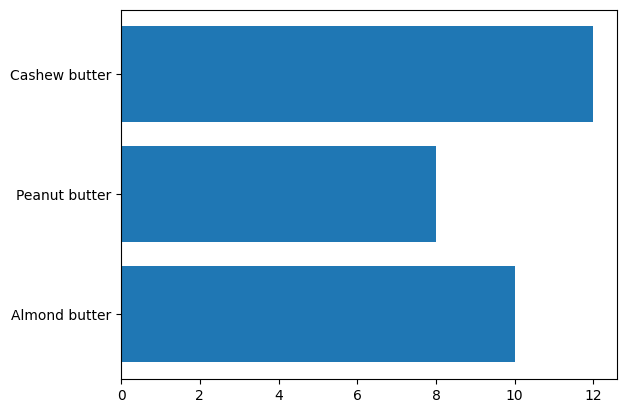

In [76]:
fig, ax = plt.subplots()
ax.barh(list(nut_butter_prices.keys()), list(nut_butter_prices.values()));

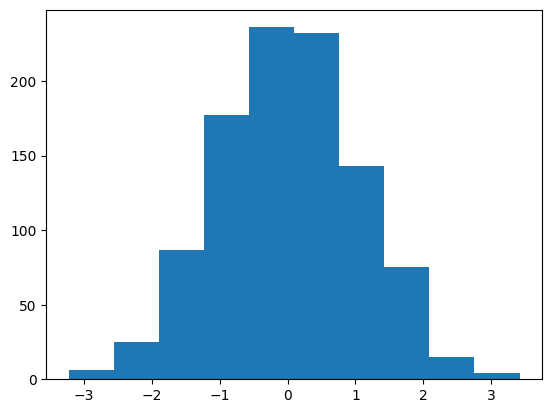

In [77]:
# Make some data from a normal distribution
x = np.random.randn(1000) # pulls data from a normal distribution

fig, ax = plt.subplots()
ax.hist(x);

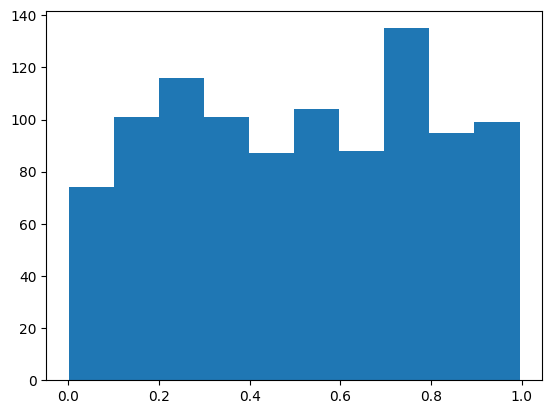

In [78]:
x = np.random.random(1000) # random data from a uniform distribution

fig, ax = plt.subplots()
ax.hist(x);

# Creating Figures with multiple Axes with Subplots

Subplots allow you to create multiple Axes on the same Figure (multiple plots within the same plot).

Subplots are helpful because you start with one plot per Figure but scale it up to more when necessary.

For example, let's create a subplot that shows many of the above datasets on the same Figure.

We can do so by creating multiple Axes with plt.subplots() and setting the nrows (number of rows) and ncols (number of columns) parameters to reflect how many Axes we'd like.

nrows and ncols parameters are multiplicative, meaning plt.subplots(nrows=2, ncols=2) will create 2*2=4 total Axes.

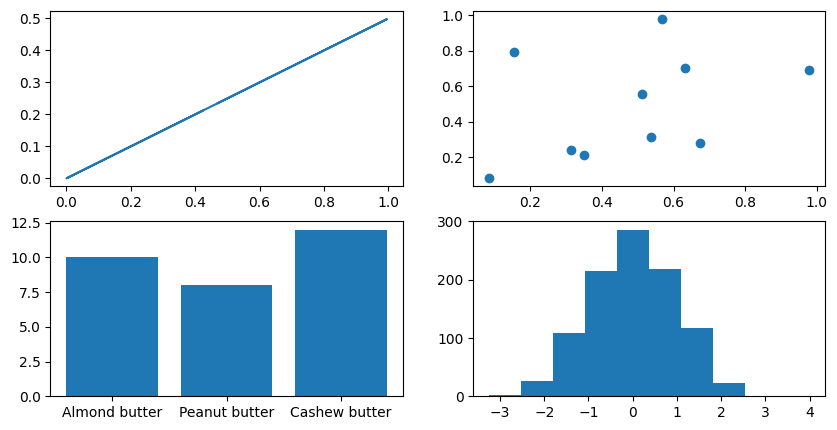

In [79]:
# Option 1: Create 4 subplots with each Axes having its own variable name
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, 
                                             ncols=2, 
                                             figsize=(10, 5))

# Plot data to each axis
ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.random(10));
ax3.bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax4.hist(np.random.randn(1000));

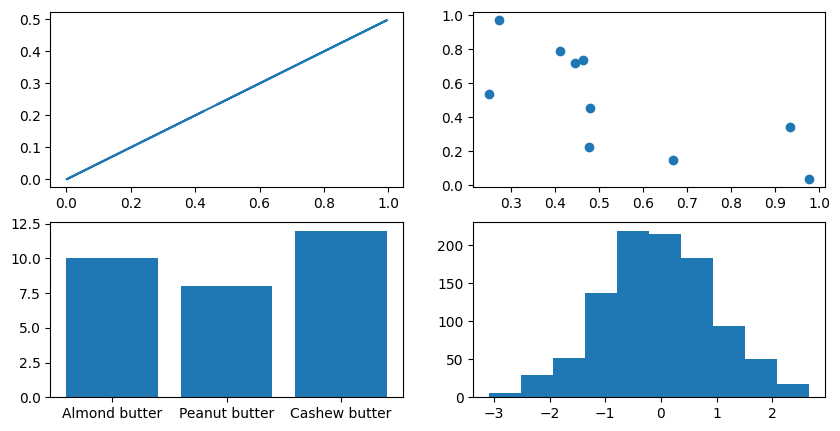

In [80]:
# Option 2: Create 4 subplots with a single ax variable
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Index the ax variable to plot data
ax[0, 0].plot(x, x/2);
ax[0, 1].scatter(np.random.random(10), np.random.random(10));
ax[1, 0].bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax[1, 1].hist(np.random.randn(1000));

In [81]:
import pandas as pd

In [82]:
# Let's import the car_sales dataset 
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales.csv") 

In [83]:
# Start with some dummy data
ts = pd.Series(np.random.randn(1000),
               index=pd.date_range('1/1/2025', periods=1000))
# Note: ts = short for time series (data over time)
ts

2025-01-01    0.432770
2025-01-02   -1.459283
2025-01-03    1.097602
2025-01-04   -0.791683
2025-01-05   -0.328267
                ...   
2027-09-23    1.140705
2027-09-24   -0.464466
2027-09-25    0.008294
2027-09-26    0.577824
2027-09-27   -0.100526
Freq: D, Length: 1000, dtype: float64

<Axes: >

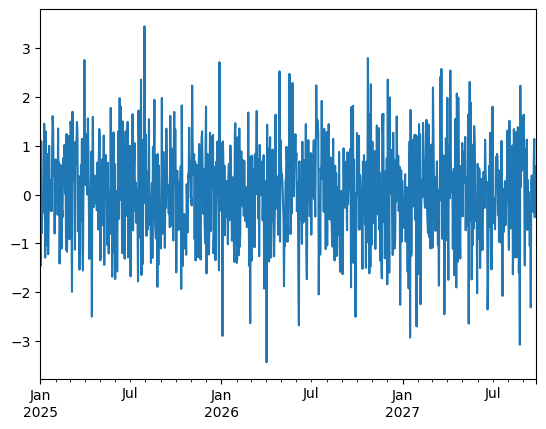

In [84]:
ts.plot()

In [85]:
# Add up the values cumulatively
ts.cumsum()

2025-01-01     0.432770
2025-01-02    -1.026513
2025-01-03     0.071089
2025-01-04    -0.720594
2025-01-05    -1.048861
                ...    
2027-09-23    47.824979
2027-09-24    47.360513
2027-09-25    47.368807
2027-09-26    47.946631
2027-09-27    47.846106
Freq: D, Length: 1000, dtype: float64

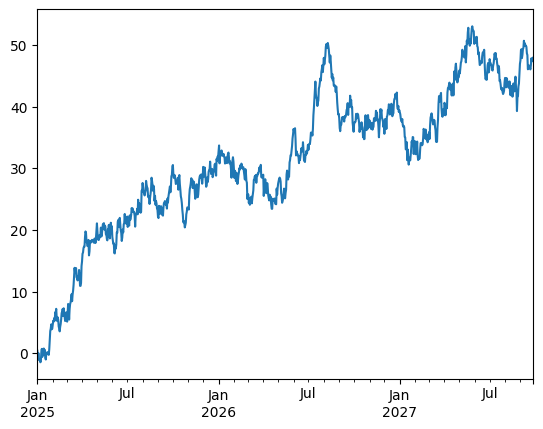

In [86]:
# Plot the values over time with a line plot (note: both of these will return the same thing)
# ts.cumsum().plot() # kind="line" is set by default
ts.cumsum().plot(kind="line");

In [87]:
# Import the car sales data 
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales.csv")

# Remove price column symbols
car_sales["Price"] = car_sales["Price"].str.replace('[\$\,\.]', '', 
                                                    regex=True) # Tell pandas to replace using regex
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [88]:
# Remove last two zeros
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [89]:
# Add a date column
car_sales["Sale Date"] = pd.date_range("1/1/2024", periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2024-01-01
1,Honda,Red,87899,4,5000,2024-01-02
2,Toyota,Blue,32549,3,7000,2024-01-03
3,BMW,Black,11179,5,22000,2024-01-04
4,Nissan,White,213095,4,3500,2024-01-05
5,Toyota,Green,99213,4,4500,2024-01-06
6,Honda,Blue,45698,4,7500,2024-01-07
7,Honda,Blue,54738,4,7000,2024-01-08
8,Toyota,White,60000,4,6250,2024-01-09
9,Nissan,White,31600,4,9700,2024-01-10


In [90]:
# Make total sales column (doesn't work, adds as string)
#car_sales["Total Sales"] = car_sales["Price"].cumsum()

# Oops... want them as int's not string
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2024-01-01,4000
1,Honda,Red,87899,4,5000,2024-01-02,9000
2,Toyota,Blue,32549,3,7000,2024-01-03,16000
3,BMW,Black,11179,5,22000,2024-01-04,38000
4,Nissan,White,213095,4,3500,2024-01-05,41500
5,Toyota,Green,99213,4,4500,2024-01-06,46000
6,Honda,Blue,45698,4,7500,2024-01-07,53500
7,Honda,Blue,54738,4,7000,2024-01-08,60500
8,Toyota,White,60000,4,6250,2024-01-09,66750
9,Nissan,White,31600,4,9700,2024-01-10,76450


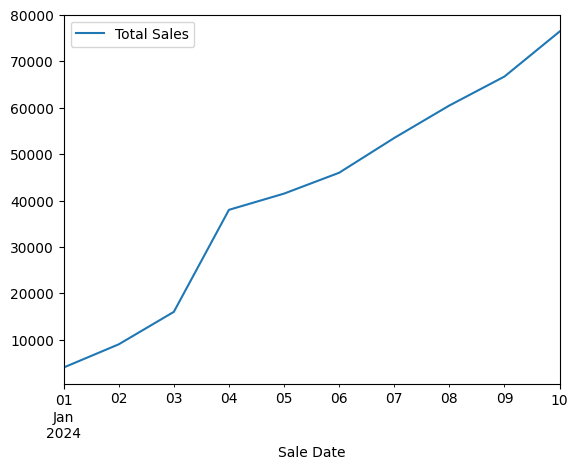

In [91]:
car_sales.plot(x='Sale Date', y='Total Sales');

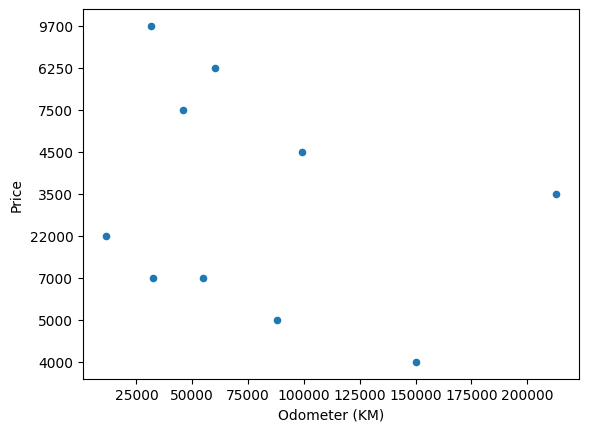

In [92]:
# Note: In previous versions of matplotlib and pandas, have the "Price" column as a string would
# return an error
car_sales["Price"] = car_sales["Price"].astype(str)

# Plot a scatter plot
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter");

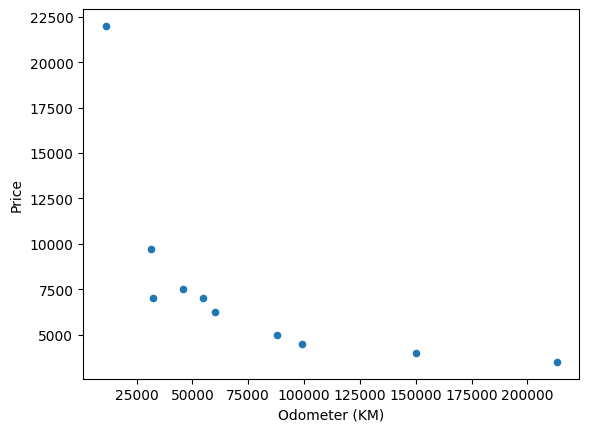

In [93]:
# Convert Price to int
car_sales["Price"] = car_sales["Price"].astype(int)

# Plot a scatter plot
car_sales.plot(x="Odometer (KM)", y="Price", kind='scatter');

In [94]:
# Create 10 random samples across 4 columns
x = np.random.rand(10, 4)
x

array([[0.55893111, 0.50984299, 0.69947453, 0.06540418],
       [0.49350841, 0.22400719, 0.62776971, 0.74581722],
       [0.09238386, 0.44872346, 0.16927568, 0.28256368],
       [0.71248944, 0.05686676, 0.93162545, 0.82527989],
       [0.27105125, 0.86336775, 0.05765722, 0.47556839],
       [0.07860196, 0.49197748, 0.38231978, 0.19564823],
       [0.76723792, 0.39782768, 0.63295193, 0.83561682],
       [0.62477832, 0.81992399, 0.89176488, 0.39234704],
       [0.34915801, 0.06034835, 0.50048372, 0.60439046],
       [0.49760267, 0.78864126, 0.86742831, 0.95519955]])

In [95]:
# Turn the data into a DataFrame
df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,0.558931,0.509843,0.699475,0.065404
1,0.493508,0.224007,0.627770,0.745817
2,0.092384,0.448723,0.169276,0.282564
3,0.712489,0.056867,0.931625,0.825280
4,0.271051,0.863368,0.057657,0.475568
5,0.078602,0.491977,0.382320,0.195648
6,0.767238,0.397828,0.632952,0.835617
7,0.624778,0.819924,0.891765,0.392347
8,0.349158,0.060348,0.500484,0.604390
9,0.497603,0.788641,0.867428,0.955200


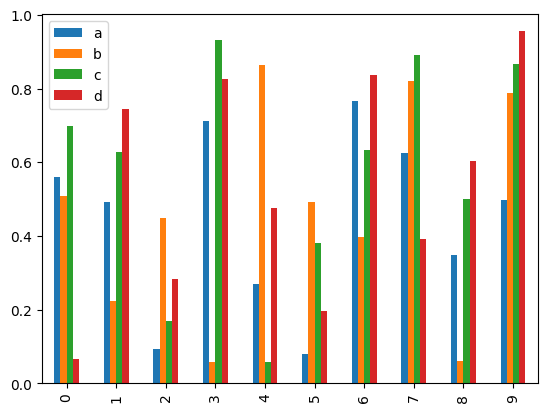

In [96]:
# Plot a bar chart
df.plot.bar();

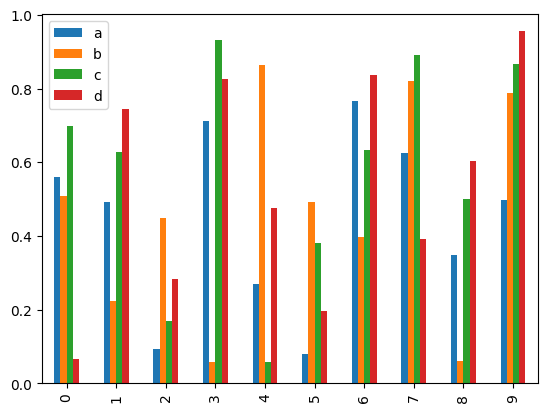

In [97]:
# Plot a bar chart with the kind parameter
df.plot(kind='bar');

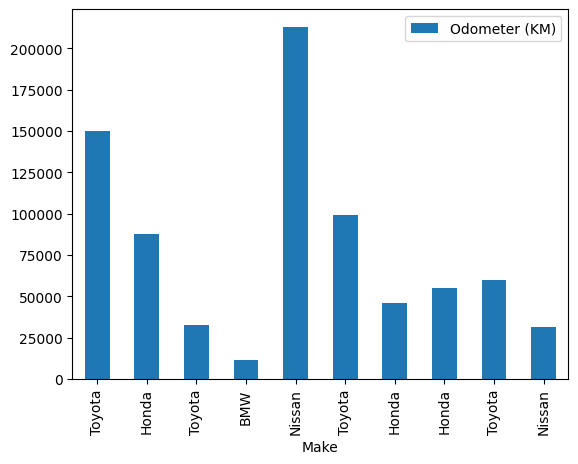

In [98]:
# Plot a bar chart from car_sales DataFrame
car_sales.plot(x="Make", 
               y="Odometer (KM)", 
               kind="bar");

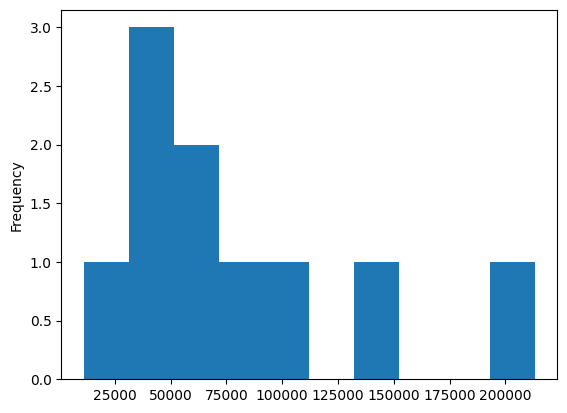

In [99]:
car_sales["Odometer (KM)"].plot.hist(bins=10); # default number of bins (or groups) is 10

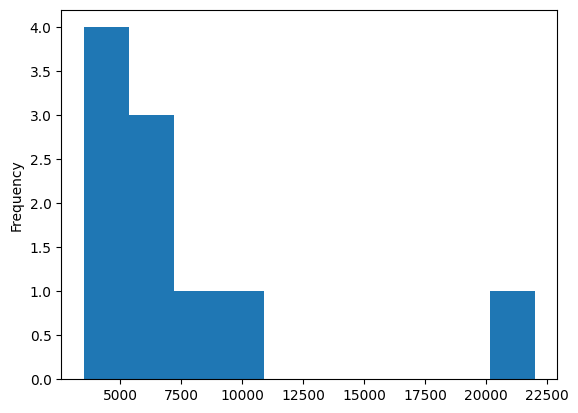

In [100]:
# Create a histogram of the Price column
car_sales["Price"].plot.hist(bins=10);

In [101]:
# Import the heart disease dataset
# Note: The following two lines create the same DataFrame, one just loads data from a local filepath where as the other downloads it directly from a URL.

# heart_disease = pd.read_csv("../data/heart-disease.csv") # load from local file path (requires data to be downloaded)
heart_disease = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv") # load directly from raw URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/heart-disease.csv)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


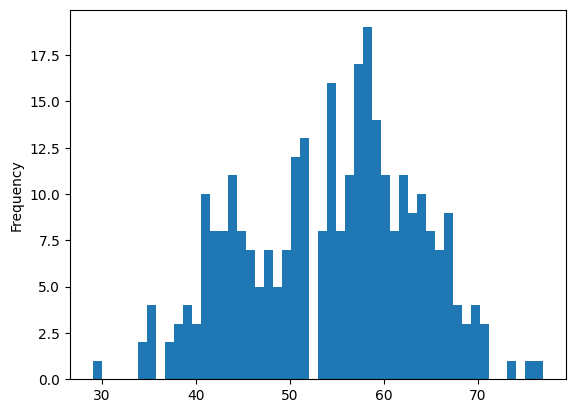

In [102]:
# Create a histogram of the age column
heart_disease["age"].plot.hist(bins=50);

In [103]:
# Perform data analysis on patients over 50
over_50 = heart_disease[heart_disease["age"] > 50]
over_50

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1,0
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


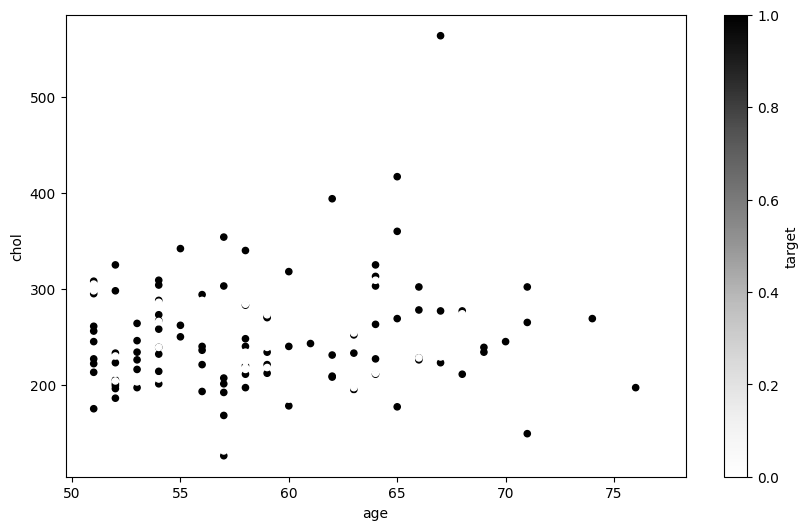

In [104]:
# Create a scatter plot directly from the pandas DataFrame
over_50.plot(kind="scatter",
             x="age", 
             y="chol", 
             c="target", # colour the dots by target value
             figsize=(10, 6));

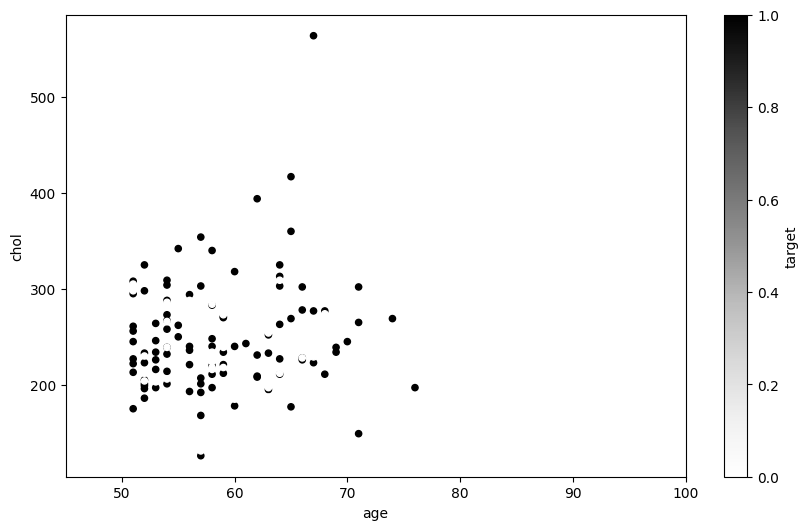

In [105]:
# Create a Figure and Axes instance
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data from the DataFrame to the ax object
over_50.plot(kind="scatter", 
             x="age", 
             y="chol", 
             c="target", 
             ax=ax); # set the target Axes

# Customize the x-axis limits (to be within our target age ranges)
ax.set_xlim([45, 100]);

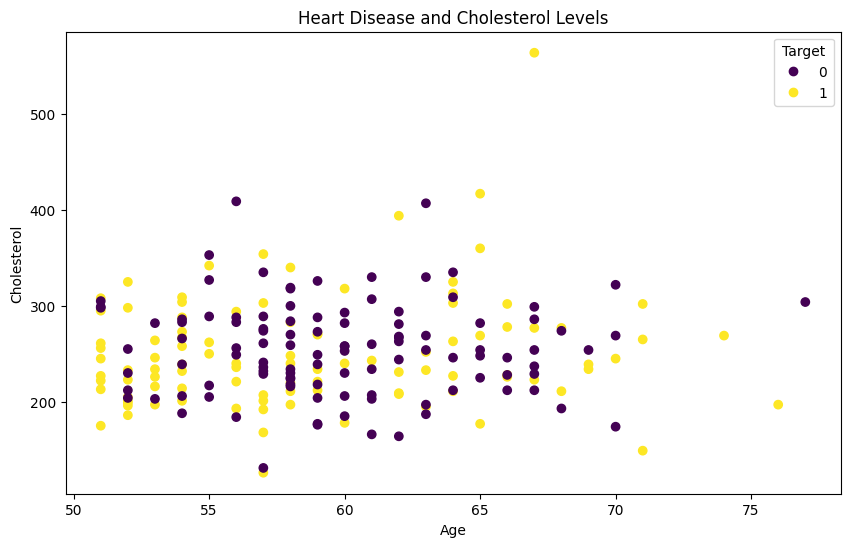

In [106]:
# Create Figure and Axes instance
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data directly to the Axes intance
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"]) # Colour the data with the "target" column

# Customize the plot parameters 
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");

# Setup the legend
ax.legend(*scatter.legend_elements(), 
          title="Target");

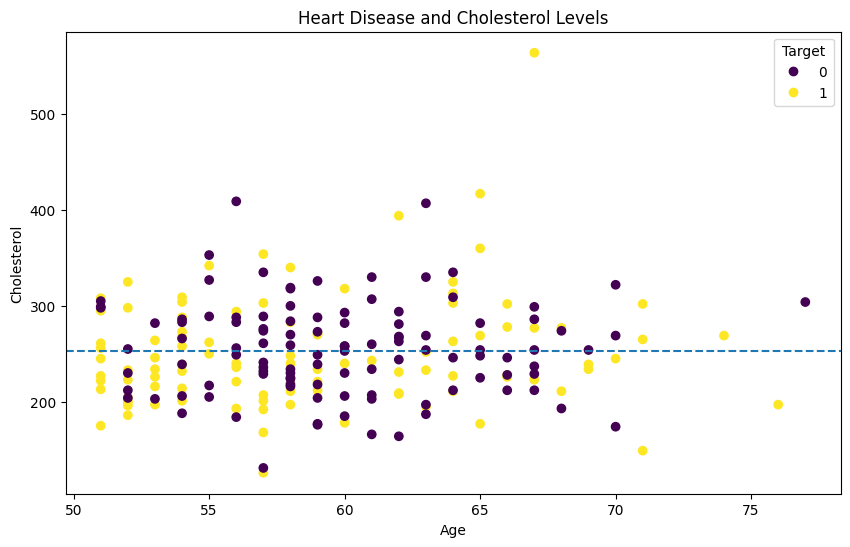

In [107]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"])

# Customize the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");

# Add a legned
ax.legend(*scatter.legend_elements(), title="Target")

# Add a meanline
ax.axhline(over_50["chol"].mean(), linestyle="--"); # style the line to make it look nice

# Plotting multiple plots on the same figure (adding another plot to an existing one)

Sometimes you'll want to visualize multiple features of a dataset or results of a model in one Figure.

You can achieve this by adding data to multiple Axes on the same Figure.

The plt.subplots() method helps you create Figures with a desired number of Axes in a desired figuration.

Using nrows (number of rows) and ncols (number of columns) parameters you can control the number of Axes on the Figure.

For example:

- nrows=2, ncols=1 = 2x1 = a Figure with 2 Axes

- nrows=5, ncols=5 = 5x5 = a Figure with 25 Axes

Let's create a plot with 2 Axes.

One the first Axes (Axes 0), we'll plot heart disease against cholesterol levels (chol).

On the second Axes (Axis 1), we'll plot heart disease against max heart rate levels (thalach).

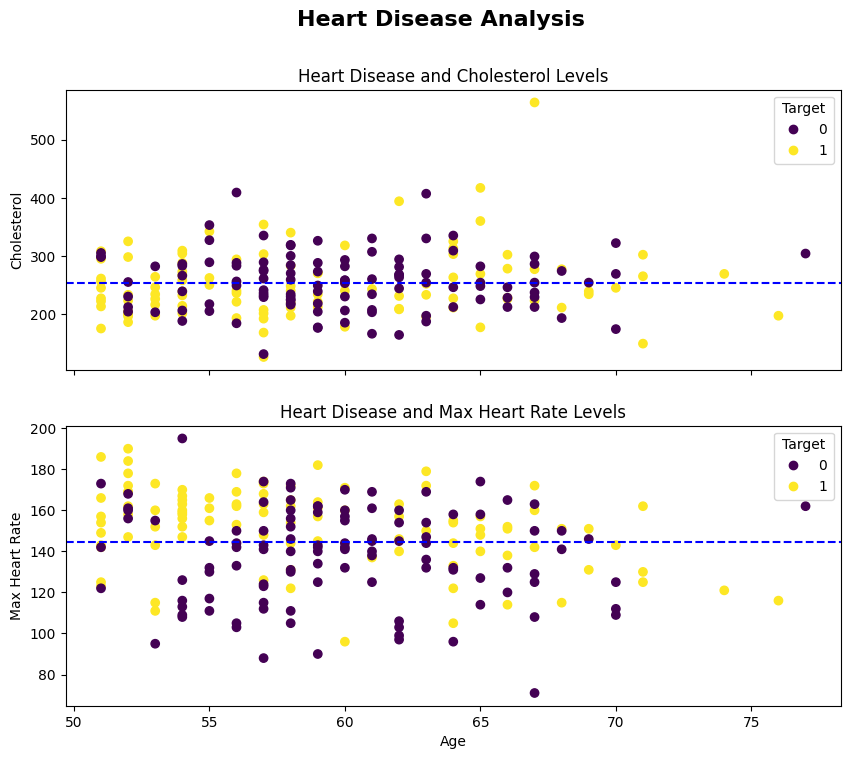

In [108]:
# Setup plot (2 rows, 1 column)
fig, (ax0, ax1) = plt.subplots(nrows=2, # 2 rows
                               ncols=1, # 1 column 
                               sharex=True, # both plots should use the same x-axis 
                               figsize=(10, 8))

# ---------- Axis 0: Heart Disease and Cholesterol Levels ----------

# Add data for ax0
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"])
# Customize ax0
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")
ax0.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")

# ---------- Axis 1: Heart Disease and Max Heart Rate Levels ----------

# Add data for ax1
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"])

# Customize ax1
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")
ax1.legend(*scatter.legend_elements(), title="Target")

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color='b', 
            linestyle='--', 
            label="Average")

# Title the figure
fig.suptitle('Heart Disease Analysis', 
             fontsize=16, 
             fontweight='bold');

In [109]:
# Check the available styles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

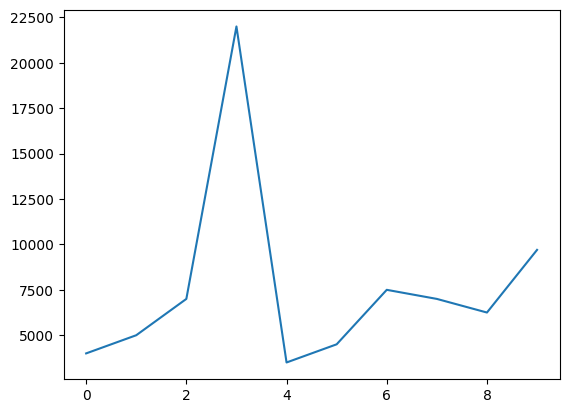

In [110]:
# Plot before changing style
car_sales["Price"].plot();

In [111]:
# Change the style of our future plots
plt.style.use("seaborn-v0_8-whitegrid")

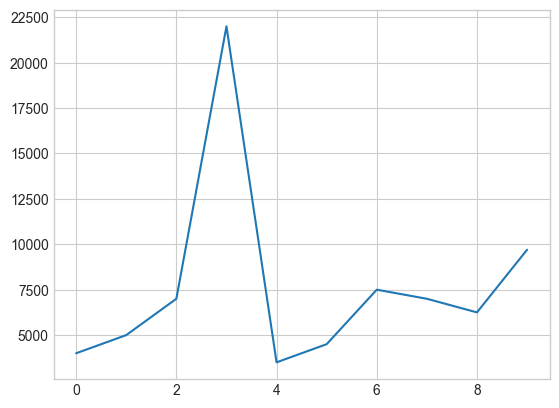

In [112]:
# Plot the same plot as before
car_sales["Price"].plot();

In [113]:
# Change the plot style
plt.style.use("fivethirtyeight")

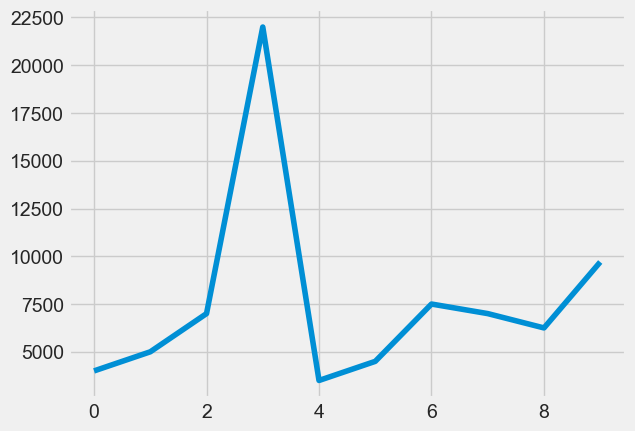

In [114]:
car_sales["Price"].plot();

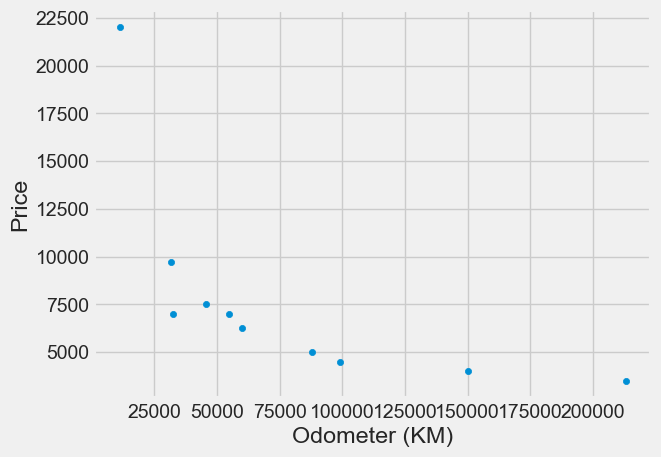

In [115]:
car_sales.plot(x="Odometer (KM)", 
               y="Price", 
               kind="scatter");

In [116]:
# Change the plot style
plt.style.use("ggplot")

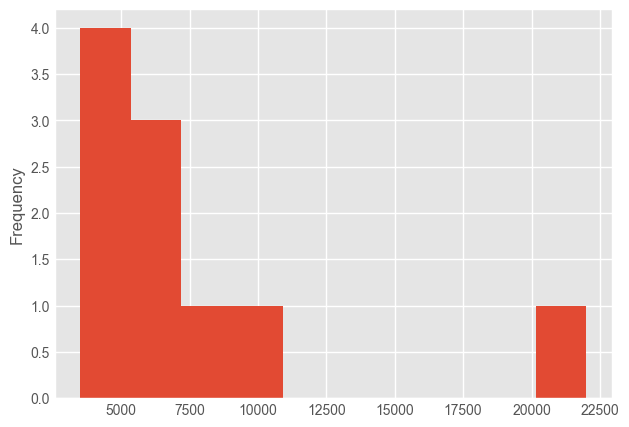

In [119]:
car_sales["Price"].plot.hist(bins=10);

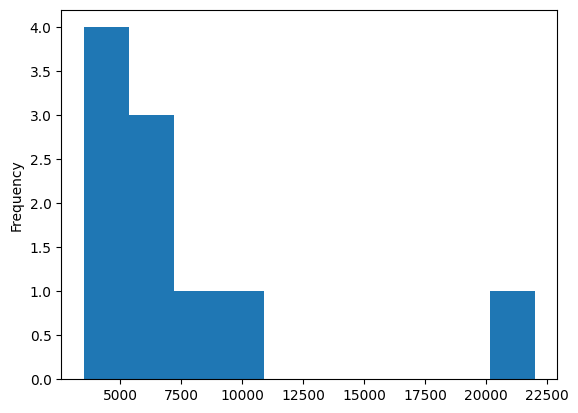

In [120]:
# Change the plot style back to the default 
plt.style.use("default")
car_sales["Price"].plot.hist();

In [121]:
# Create random data
x = np.random.randn(10, 4)
x

array([[-1.14457826, -1.87992816,  0.69969409, -0.54034314],
       [-0.68331379, -0.37769675,  1.29306068,  0.31333904],
       [ 0.16256269, -0.59507826,  1.61927359, -1.29327989],
       [ 0.63184608, -0.43834462, -0.15342019, -0.69528294],
       [-0.35279403, -0.47720171, -1.02597991, -1.07706614],
       [-0.96205718, -0.08507361,  2.14481113,  0.38454757],
       [-0.42828866,  0.60816916,  1.65663634,  0.21873904],
       [-0.61681139, -1.30123185,  0.08814537, -1.80643455],
       [-1.20168276,  0.41291547, -2.5798714 ,  0.06929639],
       [-0.28405096, -0.88112523, -0.96993256, -0.70846246]])

In [122]:
# Turn data into DataFrame with simple column names
df = pd.DataFrame(x, 
                  columns=['a', 'b', 'c', 'd'])
df

,a,b,c,d
0,-1.144578,-1.879928,0.699694,-0.540343
1,-0.683314,-0.377697,1.293061,0.313339
2,0.162563,-0.595078,1.619274,-1.293280
3,0.631846,-0.438345,-0.153420,-0.695283
4,-0.352794,-0.477202,-1.025980,-1.077066
5,-0.962057,-0.085074,2.144811,0.384548
6,-0.428289,0.608169,1.656636,0.218739
7,-0.616811,-1.301232,0.088145,-1.806435
8,-1.201683,0.412915,-2.579871,0.069296
9,-0.284051,-0.881125,-0.969933,-0.708462


matplotlib.axes._axes.Axes

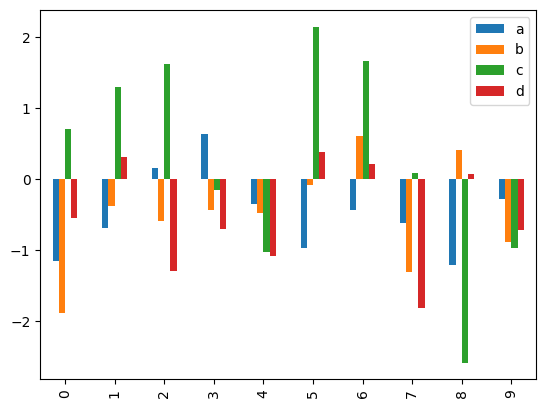

In [123]:
# Create a bar plot
ax = df.plot(kind="bar")

# Check the type of the ax variable
type(ax)

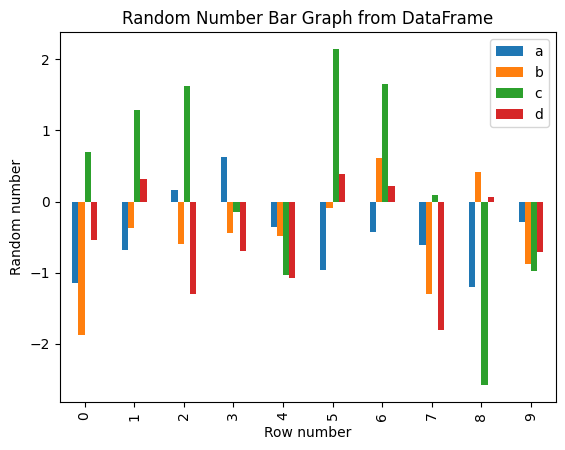

In [124]:
# Recreate the ax object
ax = df.plot(kind="bar")

# Set various attributes
ax.set(title="Random Number Bar Graph from DataFrame", 
       xlabel="Row number", 
       ylabel="Random number");

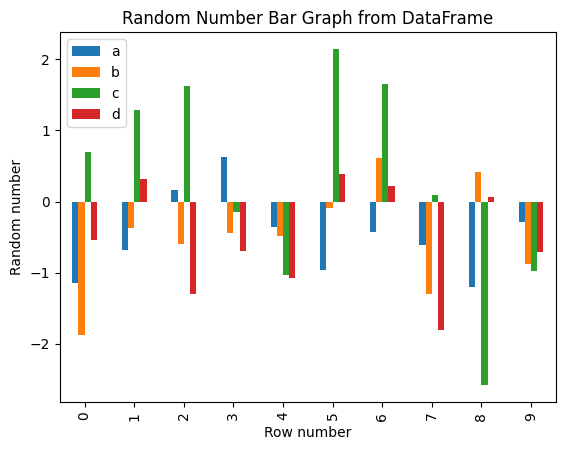

In [126]:
# Recreate the ax object
ax = df.plot(kind="bar")

# Set various attributes
ax.set(title="Random Number Bar Graph from DataFrame", 
       xlabel="Row number", 
       ylabel="Random number")

# Change the legend position
ax.legend(loc="upper left");

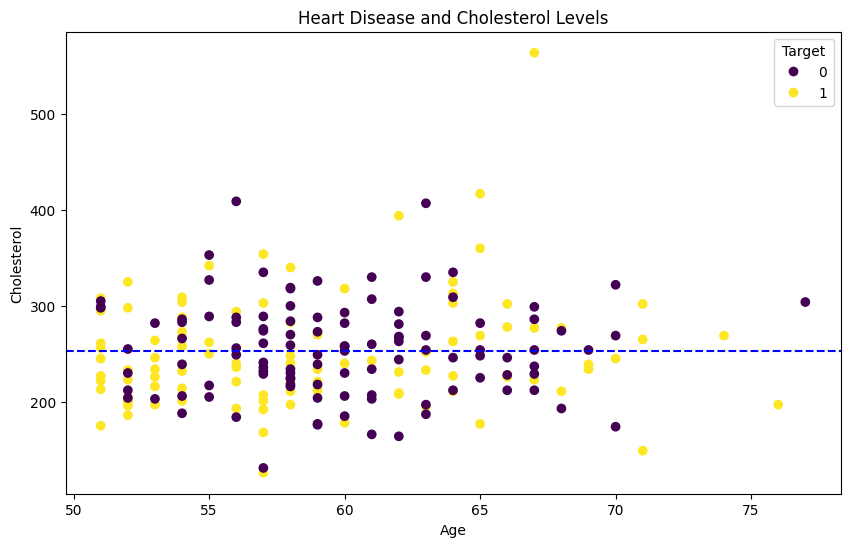

In [127]:
# Setup the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Create a scatter plot with no cmap change (use default colormap)
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"],
                     cmap="viridis") # default cmap value

# Add attributes to the plot
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
ax.axhline(y=over_50["chol"].mean(), 
           c='b', 
           linestyle='--', 
           label="Average");
ax.legend(*scatter.legend_elements(), 
          title="Target");

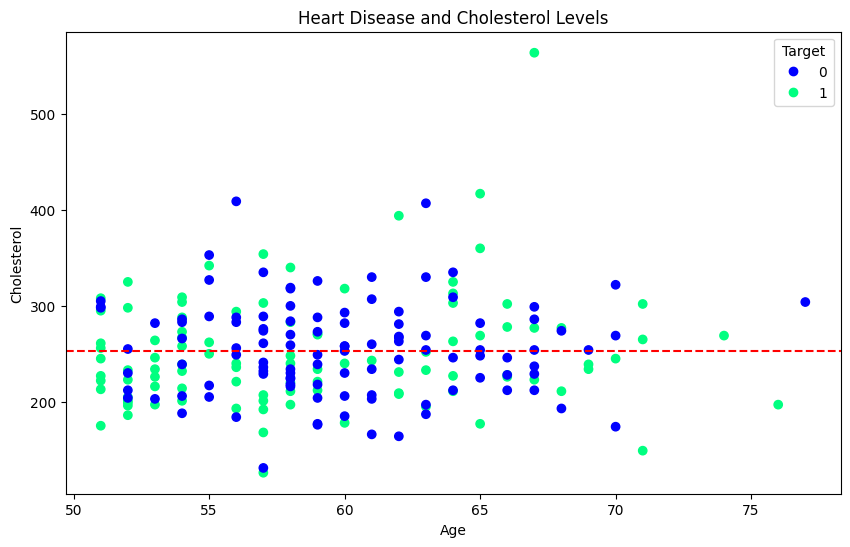

In [128]:
fig, ax = plt.subplots(figsize=(10, 6))

# Setup scatter plot with different cmap
scatter = ax.scatter(over_50["age"], 
                     over_50["chol"], 
                     c=over_50["target"], 
                     cmap="winter") # Change cmap value 

# Add attributes to the plot with different color line
ax.set(title="Heart Disease and Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol")
ax.axhline(y=over_50["chol"].mean(), 
           color="r", # Change color of line to "r" (for red)
           linestyle='--', 
           label="Average");
ax.legend(*scatter.legend_elements(), 
          title="Target");

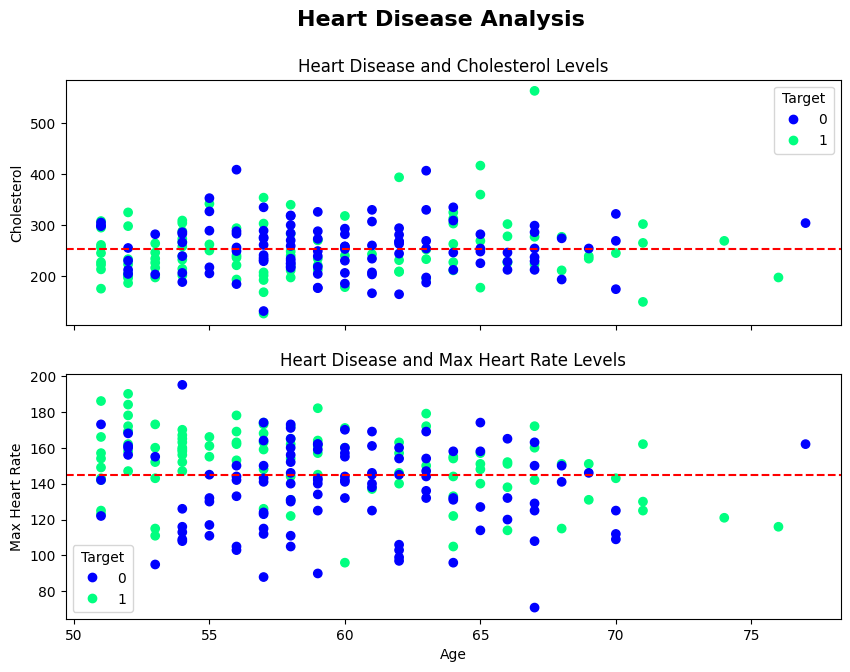

In [129]:
# Recreate double Axes plot from above with colour updates 
fig, (ax0, ax1) = plt.subplots(nrows=2, 
                               ncols=1, 
                               sharex=True, 
                               figsize=(10, 7))

# ---------- Axis 0 ----------
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"],
                      cmap="winter")
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol")

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color="r", 
            linestyle="--", 
            label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# ---------- Axis 1 ----------
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"],
                      cmap="winter")
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate")

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color="r", 
            linestyle="--", 
            label="Average");
ax1.legend(*scatter.legend_elements(), 
           title="Target")

# Title the figure
fig.suptitle("Heart Disease Analysis", 
             fontsize=16, 
             fontweight="bold");

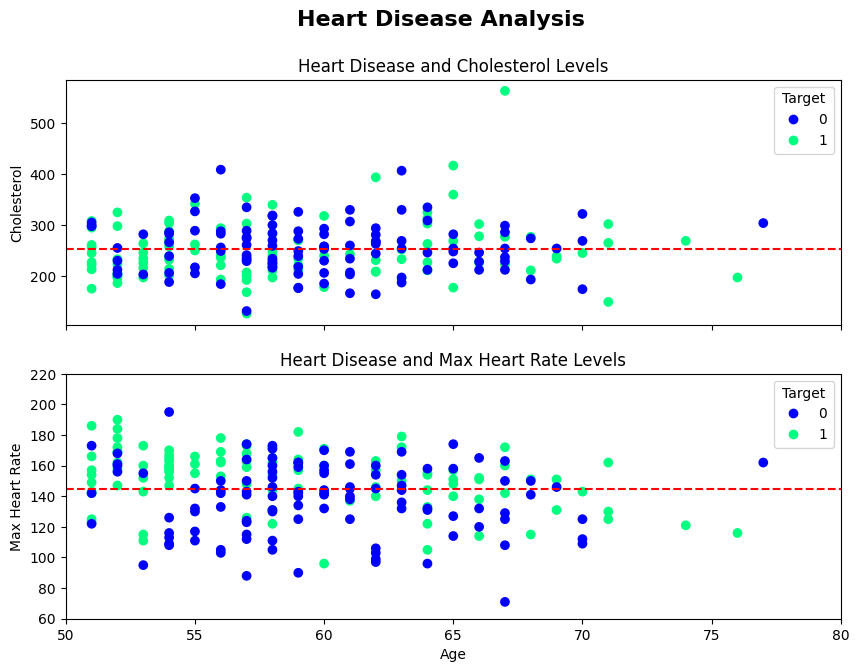

In [133]:
# Recreate the plot from above with custom x and y axis ranges
fig, (ax0, ax1) = plt.subplots(nrows=2, 
                               ncols=1, 
                               sharex=True, 
                               figsize=(10, 7))
scatter = ax0.scatter(over_50["age"], 
                      over_50["chol"], 
                      c=over_50["target"],
                      cmap='winter')
ax0.set(title="Heart Disease and Cholesterol Levels",
        ylabel="Cholesterol",
        xlim=[50, 80]) # set the x-axis ranges 

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), 
            color="r", 
            linestyle="--", 
            label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# Axis 1, 1 (row 1, column 1)
scatter = ax1.scatter(over_50["age"], 
                      over_50["thalach"], 
                      c=over_50["target"],
                      cmap='winter')
ax1.set(title="Heart Disease and Max Heart Rate Levels",
        xlabel="Age",
        ylabel="Max Heart Rate",
        ylim=[60, 220]) # change the y-axis range

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), 
            color="r", 
            linestyle="--", 
            label="Average");
ax1.legend(*scatter.legend_elements(), 
           title="Target")

# Title the figure
fig.suptitle("Heart Disease Analysis", 
             fontsize=16, 
             fontweight="bold");

In [134]:
# Check the supported filetypes
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

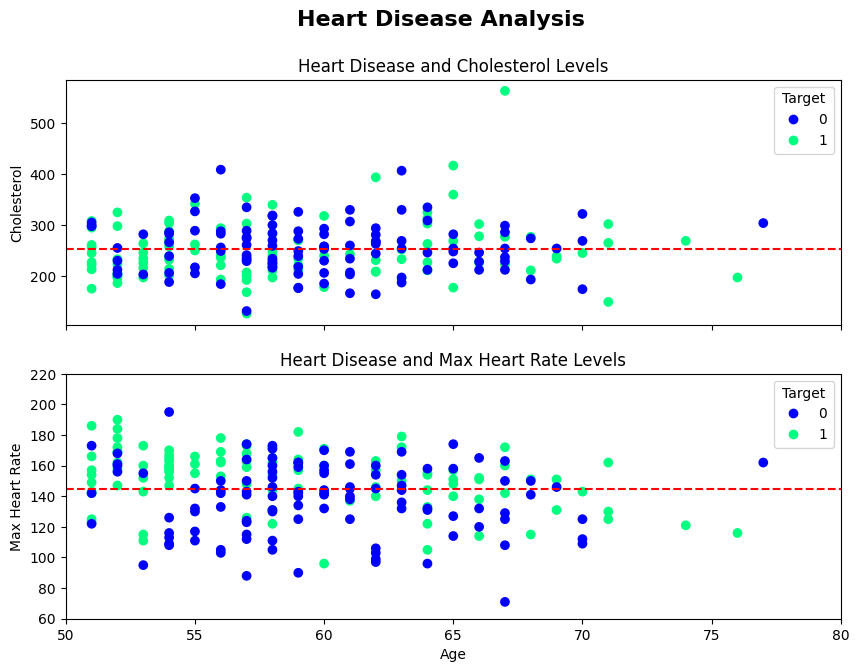

In [135]:
fig

In [136]:
# Save the file
fig.savefig(fname="./heart-disease-analysis.png",
            dpi=100)